In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from rdkit.Chem import MolFromSmiles, GetMolFrags, MolToSmiles
from rdkit.Chem.Draw import MolsToGridImage

import sys
sys.path.append('../')
import FragShapley

/home/jannik/Documents/studies/phd/03_work/20_FragShapley/FragShapley/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
plt.style.use('style.mplstyle')
sns.set_context('talk', font_scale=1.0)
fig_folder = os.path.abspath("figures/")

# 1. Load Shapley Values

In [3]:
model = 'GCN'
split = 0


df_expl = pd.read_pickle(f'../4_mutagenicity/{model.lower()}_classification_hansen/df_explanation.pkl')
df_expl = df_expl.loc[df_expl.split == split]
df_expl.head()

,model,dataset,split,smiles,y_true,y_pred,y_pred_proba,fragExplainer_result,fragExplainer_expected_value,frag_to_atom_ids
0,GCN,Hansen,0,O=C(O)c1cc([N+](=O)[O-])cc2cccnc12,1,1.0,0.899424,"{0: -4.898705959320068, 1: 7.668901085853577}",0.359079,"{0: [0, 1, 2], 1: [3, 4, 5, 6, 7, 8, 9, 10, 11..."
1,GCN,Hansen,0,Cc1cc2c(nc(N)n2C)c2ncc(-c3ccccc3)nc12,1,1.0,0.855699,"{0: 3.9027034044265747, 1: -1.5433303713798523}",0.359079,"{0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,..."
2,GCN,Hansen,0,CCN(N=O)/C(C=O)=N/O,1,1.0,0.987764,{0: 4.970329761505127},0.359079,"{0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}"
3,GCN,Hansen,0,C=CC(=O)NCNC(=O)C=C,1,0.0,0.240282,"{0: 0.7583920756975809, 1: -2.0885531306266785...",0.359079,"{0: [0, 1, 2, 3], 1: [4, 5, 6], 2: [7, 8, 9, 10]}"
4,GCN,Hansen,0,Cc1ccccc1-c1ccccc1,0,0.0,0.092938,"{0: -0.33955955505371094, 1: -1.3593494892120361}",0.359079,"{0: [0, 1, 2, 3, 4, 5, 6], 1: [7, 8, 9, 10, 11..."


In [4]:
if not "fragExplainer_expected_value_logits" in df_expl.columns:
    df_expl["fragExplainer_expected_value_logits"] = df_expl.fragExplainer_expected_value.apply(FragShapley.fragshapley.proba_to_logit)

In [5]:
df_expl.columns

Index(['model', 'dataset', 'split', 'smiles', 'y_true', 'y_pred',
       'y_pred_proba', 'fragExplainer_result', 'fragExplainer_expected_value',
       'frag_to_atom_ids', 'fragExplainer_expected_value_logits'],
      dtype='object')

# 2. Obtain List of Non-Toxic Fragments

In [6]:
df_expl['fragments'] = df_expl.smiles.apply(FragShapley.utils.get_BRICS_fragments_as_SMILES)
# get the values of the Explainer as a list (currently only available as dict)
df_expl['fragExplainer_shapley_values'] = df_expl.fragExplainer_result.apply(lambda x: list(x.values()))
# create a dataframe of all fragments (contains duplicates) and the corresponding Shapley Value
df_fragments = df_expl[['fragments', 'model', 'fragExplainer_shapley_values']].explode(['fragments', 'fragExplainer_shapley_values'], ignore_index=True)

In [7]:
df_fragments = df_fragments.groupby(['fragments', 'model']).agg([len, 'mean', 'std', list]) # will throw warning veacuse of error when calculating std for a single measurement
df_fragments = df_fragments.reset_index() # reset so that 'fragments' is a column again and no longer the index
df_fragments.columns = [col[0] if col[1]=='' else col[1] for col in df_fragments.columns.values] # rename, choose 'fragments' for first column, for the other simply len, mean, std

In [8]:
df_fragments.head()

,fragments,model,len,mean,std,list
0,*=C(C(=O)O)C(Cl)Cl,GCN,1,-0.269279,NaN,[-0.26927947998046875]
1,*=C(C)C,GCN,6,-1.798866,1.299177,"[-0.05723097909774105, -1.0941035126646361, -1..."
2,*=C(C)C#N,GCN,1,-3.456076,NaN,[-3.456075668334961]
3,*=C(C)Cl,GCN,1,-0.225729,NaN,[-0.22572851181030273]
4,*=C(C)n1ccnc1,GCN,1,0.603192,NaN,[0.6031924337148665]


# 3. Obtain Molecule to Optimize

Ideally a molecule with at least two fragments contributing negatively

In [9]:
df_mol = df_expl.loc[(df_expl.y_true == 1) & (df_expl.y_pred == 1)]

In [10]:
df_mol = df_mol.loc[df_mol.fragExplainer_shapley_values.apply(lambda x: len(x) > 2)]

In [11]:
index = 0

# extract data from row
row = df_mol.iloc[index]

smiles = row.smiles
y_pred_proba = row.y_pred_proba
explainer_result = row.fragExplainer_result
expected_value = row.fragExplainer_expected_value
frag_to_atom_ids = row.frag_to_atom_ids

contributions = FragShapley.visualization.get_atom_contribution_from_result_dict(smiles=row.smiles,
                                                                                 results_dict=row.fragExplainer_result,
                                                                                 frag_to_atom_ids=row.frag_to_atom_ids)
out = FragShapley.visualization.visualize_contributions_new(smiles=row.smiles,
                                                            contributions=row.fragExplainer_result.values(),
                                                            frag_to_atom_ids=row.frag_to_atom_ids,
                                                            min=-12,
                                                            max=12,
                                                            colormap='bwr')
with open(os.path.join(fig_folder, f"2_mutagenicity_optimization_mol_{model}.svg"), "w") as f:
    f.write(out.data)

In [12]:
# replace negatively contributing ones
frags_to_replace = [row.fragments[i] for i, v in enumerate(row.fragExplainer_shapley_values) if v > 0]

# 4. Replace Fragments

In [13]:
from rdkit.Chem.BRICS import FindBRICSBonds, BreakBRICSBonds
from rdkit.Chem import molzipFragments
from rdkit.Chem import Mol

def remove_atom_map_num(mol):
    mn = Mol(mol)
    for at in mn.GetAtoms():
        at.SetAtomMapNum(0)
    return mn

def isotope_info_to_atom_map_num(mol):
    for at in mol.GetAtoms():
        if at.GetSymbol() == '*':
            info = at.GetIsotope()
            at.SetIsotope(0)
            at.SetAtomMapNum(info)
    return mol

def replace_single_BRICS_substructure_in_mol(mol, smiles_pattern, smiles_replacement):
    # start by getting the bonds that are about to be cut
    brics_bonds = list(FindBRICSBonds(mol))
    # modify in such a way, that the two atoms belonging to the same broken bond have the same isotope information
    brics_bonds_mod = [(t[0], (f'{i+1}', f'{i+1}')) for i, t in enumerate(brics_bonds)]
    # now we can break the BRICS bonds
    brics_broken = BreakBRICSBonds(mol=mol,
                                bonds=brics_bonds_mod,
                                )
    # now turn all of the isotope information into AtomMapNum information
    brics_broken = isotope_info_to_atom_map_num(brics_broken)
    brics_broken_n = remove_atom_map_num(brics_broken)

    # these fragments contain the correctly labeled fragments
    fragments = GetMolFrags(mol=brics_broken,
                            asMols=True)

    # these fragments contain no map num
    # necessary to check which fragments should be replaced
    fragments_n = GetMolFrags(mol=brics_broken_n,
                            asMols=True)
    smiles_n = [MolToSmiles(f) for f in fragments_n]
    idxs_to_replace = [idx for idx, e in enumerate(smiles_n) if e == smiles_pattern]

    output_mols = []

    for idx_to_replace in idxs_to_replace:
        new_frags = ()
        for idx, frag in enumerate(fragments):
            if idx != idx_to_replace:
                new_frags += (frag, )
            else:
                # need to replace
                frag_repl = MolFromSmiles(smiles_replacement)
                # get correct Atom Map Num
                amn = max([at.GetAtomMapNum() for at in frag.GetAtoms()])
                # set correct Atom Map Num
                for at in frag_repl.GetAtoms():
                    if at.GetSymbol() == '*':
                        at.SetAtomMapNum(amn)
                new_frags += (frag_repl, )
        try:
            output_mols.append(molzipFragments(new_frags))
        except:
            pass
        
    return output_mols

In [14]:
# get list of possible replacement frags

# filter out single attachment point

def filter_n_attachment(smiles, n):
    if smiles.count('*') == n:
        return True
    else:
        return False

df_fragments
df_fragments = df_fragments.loc[df_fragments.fragments.apply(lambda x: filter_n_attachment(x, n=1))]
df_fragments.shape

(519, 6)

In [15]:
# now filter only non-mutagneic contributing ones
df_fragments = df_fragments.loc[df_fragments['mean'] <= 0]

In [16]:
# filter out fragments which appear fewer than min_appearance times
min_appearance = 3
df_fragments = df_fragments.loc[df_fragments['len'] >= min_appearance]
df_fragments.shape

(40, 6)

In [17]:
mols, repl_frags, new_frags = [], [], []
replacement_frags = df_fragments.sort_values(by='mean').fragments.to_list()

for frag_to_remove in frags_to_replace:
    for replacement_frag in replacement_frags:
        # print(frag_to_remove, replacement_frag)
        out_mols = replace_single_BRICS_substructure_in_mol(MolFromSmiles(smiles), frag_to_remove, replacement_frag)
        mols += out_mols
        repl_frags += [frag_to_remove] * len(out_mols)
        new_frags += [replacement_frag] * len(out_mols)

In [18]:
df_single_repl = pd.DataFrame({'mol': mols,
                               'replaced_frag': repl_frags,
                               'new_frags': new_frags})
df_single_repl['smiles'] = df_single_repl.mol.apply(MolToSmiles)
df_single_repl = df_single_repl.drop_duplicates(subset='smiles')
df_single_repl

,mol,replaced_frag,new_frags,smiles
0,<rdkit.Chem.rdchem.Mol object at 0x7e3cba110f20>,*c1ccc(N(O)C(C)=O)cc1,*C(F)(F)F,FC(F)(F)Oc1ccccc1
1,<rdkit.Chem.rdchem.Mol object at 0x7e3cba111460>,*c1ccc(N(O)C(C)=O)cc1,*C(=O)O,O=C(O)Oc1ccccc1
2,<rdkit.Chem.rdchem.Mol object at 0x7e3cba111620>,*c1ccc(N(O)C(C)=O)cc1,*C1OC1(C)C,CC1(C)OC1Oc1ccccc1
3,<rdkit.Chem.rdchem.Mol object at 0x7e3cba1114d0>,*c1ccc(N(O)C(C)=O)cc1,*CCCCCCCC,CCCCCCCCOc1ccccc1
4,<rdkit.Chem.rdchem.Mol object at 0x7e3cba111700>,*c1ccc(N(O)C(C)=O)cc1,*CCCCC,CCCCCOc1ccccc1
...,...,...,...,...
67,<rdkit.Chem.rdchem.Mol object at 0x7e3cba113220>,*c1ccccc1,*C(C)C(=O)O,CC(=O)N(O)c1ccc(OC(C)C(=O)O)cc1
68,<rdkit.Chem.rdchem.Mol object at 0x7e3cba113370>,*c1ccccc1,*CO,CC(=O)N(O)c1ccc(OCO)cc1
69,<rdkit.Chem.rdchem.Mol object at 0x7e3cba1133e0>,*c1ccccc1,*OC,COOc1ccc(N(O)C(C)=O)cc1
70,<rdkit.Chem.rdchem.Mol object at 0x7e3cba113450>,*c1ccccc1,*C(=O)CC(C)C,CC(=O)N(O)c1ccc(OC(=O)CC(C)C)cc1


In [19]:
# now double replacement
# use single replaced molecules and replace the other part

mols, repl_frags, new_frags = [], [], []

for i, r in df_single_repl.iterrows():
    #print('HERE')
    already_replaced = r.replaced_frag
    if frags_to_replace[0] == already_replaced:
        to_replace = frags_to_replace[1]
    else:
        to_replace = frags_to_replace[0]

    for replacement_frag in replacement_frags:
        out_mols = replace_single_BRICS_substructure_in_mol(MolFromSmiles(r.smiles), to_replace, replacement_frag)
        mols += out_mols
        repl_frags += [to_replace] * len(out_mols)
        new_frags += [replacement_frag] * len(out_mols)

In [20]:
df_double_repl = pd.DataFrame({'mol': mols,
                               'replaced_frag': repl_frags,
                               'new_frags': new_frags})
df_double_repl['smiles'] = df_double_repl.mol.apply(MolToSmiles)
df_double_repl = df_double_repl.drop_duplicates(subset='smiles')
df_double_repl

,mol,replaced_frag,new_frags,smiles
0,<rdkit.Chem.rdchem.Mol object at 0x7e3cba1111c0>,*c1ccccc1,*C(F)(F)F,FC(F)(F)OC(F)(F)F
1,<rdkit.Chem.rdchem.Mol object at 0x7e3cba1136f0>,*c1ccccc1,*C(=O)O,O=C(O)OC(F)(F)F
2,<rdkit.Chem.rdchem.Mol object at 0x7e3cba1134c0>,*c1ccccc1,*C1OC1(C)C,CC1(C)OC1OC(F)(F)F
3,<rdkit.Chem.rdchem.Mol object at 0x7e3cba1138b0>,*c1ccccc1,*CCCCCCCC,CCCCCCCCOC(F)(F)F
4,<rdkit.Chem.rdchem.Mol object at 0x7e3cba1137d0>,*c1ccccc1,*CCCCC,CCCCCOC(F)(F)F
...,...,...,...,...
1258,<rdkit.Chem.rdchem.Mol object at 0x7e3cba0ea260>,*c1ccccc1,*C(=O)CC(C)C,COOC(=O)CC(C)C
1259,<rdkit.Chem.rdchem.Mol object at 0x7e3cba0ea110>,*c1ccccc1,*c1ccc(C)cc1,COOc1ccc(C)cc1
1294,<rdkit.Chem.rdchem.Mol object at 0x7e3cba0eb300>,*c1ccccc1,*C(=O)CC(C)C,CC(C)CC(=O)OC(=O)CC(C)C
1295,<rdkit.Chem.rdchem.Mol object at 0x7e3cba0eb1b0>,*c1ccccc1,*c1ccc(C)cc1,Cc1ccc(OC(=O)CC(C)C)cc1


# 5. Load Model an Obtain Predictions

In [21]:
import torch
import lightning as L
from torch.utils.data import DataLoader
import numpy as np

if model in ['GCN', 'MPNN']:
    classifier = torch.load(f'../4_mutagenicity/{model.lower()}_classification_hansen/models/model_{model.lower()}c_Hansen_split_{split}.pkl', weights_only=False)
    featurizer = FragShapley.Featurizer(input_format='smiles',
                                        output_format='graph')
    ds_single = FragShapley.MoleculeDataset(list_of_inputs=df_single_repl.smiles,
                                            featurizer=featurizer)
    ds_double = FragShapley.MoleculeDataset(list_of_inputs=df_double_repl.smiles,
                                            featurizer=featurizer)
    dl_single = DataLoader(dataset=ds_single,
                           batch_size=16)
    dl_double = DataLoader(dataset=ds_double,
                           batch_size=16)
    trainer = L.Trainer(accelerator='auto')
    pred_single = trainer.predict(model=classifier,
                                  dataloaders=ds_single)
    pred_double = trainer.predict(model=classifier,
                                  dataloaders=ds_double)
    
    df_single_repl['prediction'] = np.array(pred_single).squeeze()
    df_double_repl['prediction'] = np.array(pred_double).squeeze()

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/home/jannik/Documents/studies/phd/03_work/20_FragShapley/FragShapley/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


Predicting DataLoader 0: 100%|██████████| 666/666 [00:02<00:00, 286.78it/s]


In [22]:
df_single_repl

,mol,replaced_frag,new_frags,smiles,prediction
0,<rdkit.Chem.rdchem.Mol object at 0x7e3cba110f20>,*c1ccc(N(O)C(C)=O)cc1,*C(F)(F)F,FC(F)(F)Oc1ccccc1,0.113908
1,<rdkit.Chem.rdchem.Mol object at 0x7e3cba111460>,*c1ccc(N(O)C(C)=O)cc1,*C(=O)O,O=C(O)Oc1ccccc1,0.003827
2,<rdkit.Chem.rdchem.Mol object at 0x7e3cba111620>,*c1ccc(N(O)C(C)=O)cc1,*C1OC1(C)C,CC1(C)OC1Oc1ccccc1,0.022201
3,<rdkit.Chem.rdchem.Mol object at 0x7e3cba1114d0>,*c1ccc(N(O)C(C)=O)cc1,*CCCCCCCC,CCCCCCCCOc1ccccc1,0.027769
4,<rdkit.Chem.rdchem.Mol object at 0x7e3cba111700>,*c1ccc(N(O)C(C)=O)cc1,*CCCCC,CCCCCOc1ccccc1,0.048192
...,...,...,...,...,...
67,<rdkit.Chem.rdchem.Mol object at 0x7e3cba113220>,*c1ccccc1,*C(C)C(=O)O,CC(=O)N(O)c1ccc(OC(C)C(=O)O)cc1,0.531267
68,<rdkit.Chem.rdchem.Mol object at 0x7e3cba113370>,*c1ccccc1,*CO,CC(=O)N(O)c1ccc(OCO)cc1,0.519054
69,<rdkit.Chem.rdchem.Mol object at 0x7e3cba1133e0>,*c1ccccc1,*OC,COOc1ccc(N(O)C(C)=O)cc1,0.365866
70,<rdkit.Chem.rdchem.Mol object at 0x7e3cba113450>,*c1ccccc1,*C(=O)CC(C)C,CC(=O)N(O)c1ccc(OC(=O)CC(C)C)cc1,0.808909


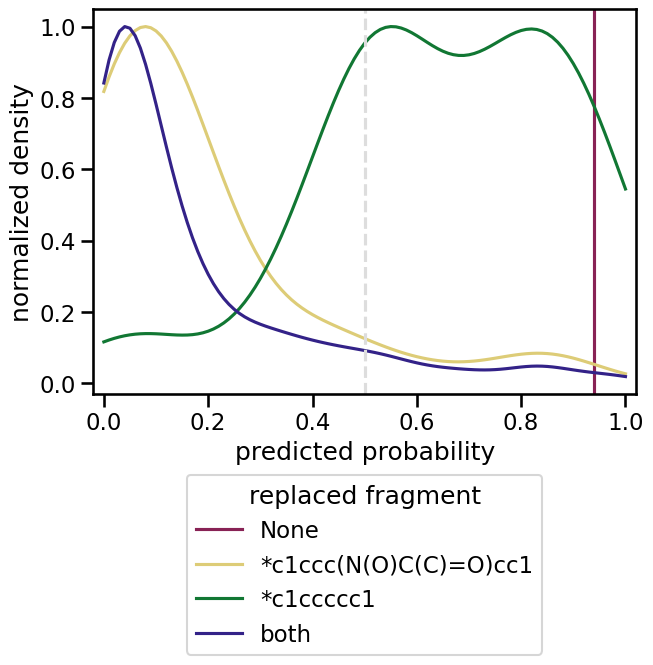

In [24]:
# visualize 
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

fig, axs = plt.subplots(1, 1, figsize=(7, 5))
axs.set_xlim(-0.02, 1.02)

# original mol
axs.axvline(row.y_pred_proba, 0, 1, c=sns.color_palette()[5], label='None')

# single replacement
x_smooth = np.linspace(0, 1, 101)
for i, rf in enumerate(df_single_repl.replaced_frag.unique()):
    df_tmp = df_single_repl.loc[df_single_repl.replaced_frag == rf]
    kde_single = gaussian_kde(df_tmp.prediction)
    y_single = kde_single(x_smooth)
    y_single =y_single / y_single.max()
    axs.plot(x_smooth, y_single, c=sns.color_palette()[2+i], label=f'{rf}')

# double replacement
kde_double = gaussian_kde(df_double_repl.prediction)
y_double = kde_double(x_smooth)
y_double = y_double / y_double.max()
axs.plot(x_smooth, y_double, c=sns.color_palette()[1], label='both')

# decision border
axs.axvline(0.5, 0, 1, ls='--', c=sns.color_palette()[-1])

axs.set_xlabel('predicted probability')
axs.set_ylabel('normalized density')

axs.legend(title='replaced fragment',
           bbox_to_anchor=(0.5, -0.18),
           loc='upper center')
fig.savefig(os.path.join(fig_folder, f'2_mutagenicity_optimization_dataset_Hansen_model_{model}_split_{split}.svg'), 
            bbox_inches='tight',
            )